Using dump_dir=/aifs4su/guhao/KVCache/kvpress/evaluation/results_debug/ruler__4096__Llama-3.1-8B-Instruct__expected_attention__cr0.0
Using pos=4068, num_layers=32, layer range=(0..31)


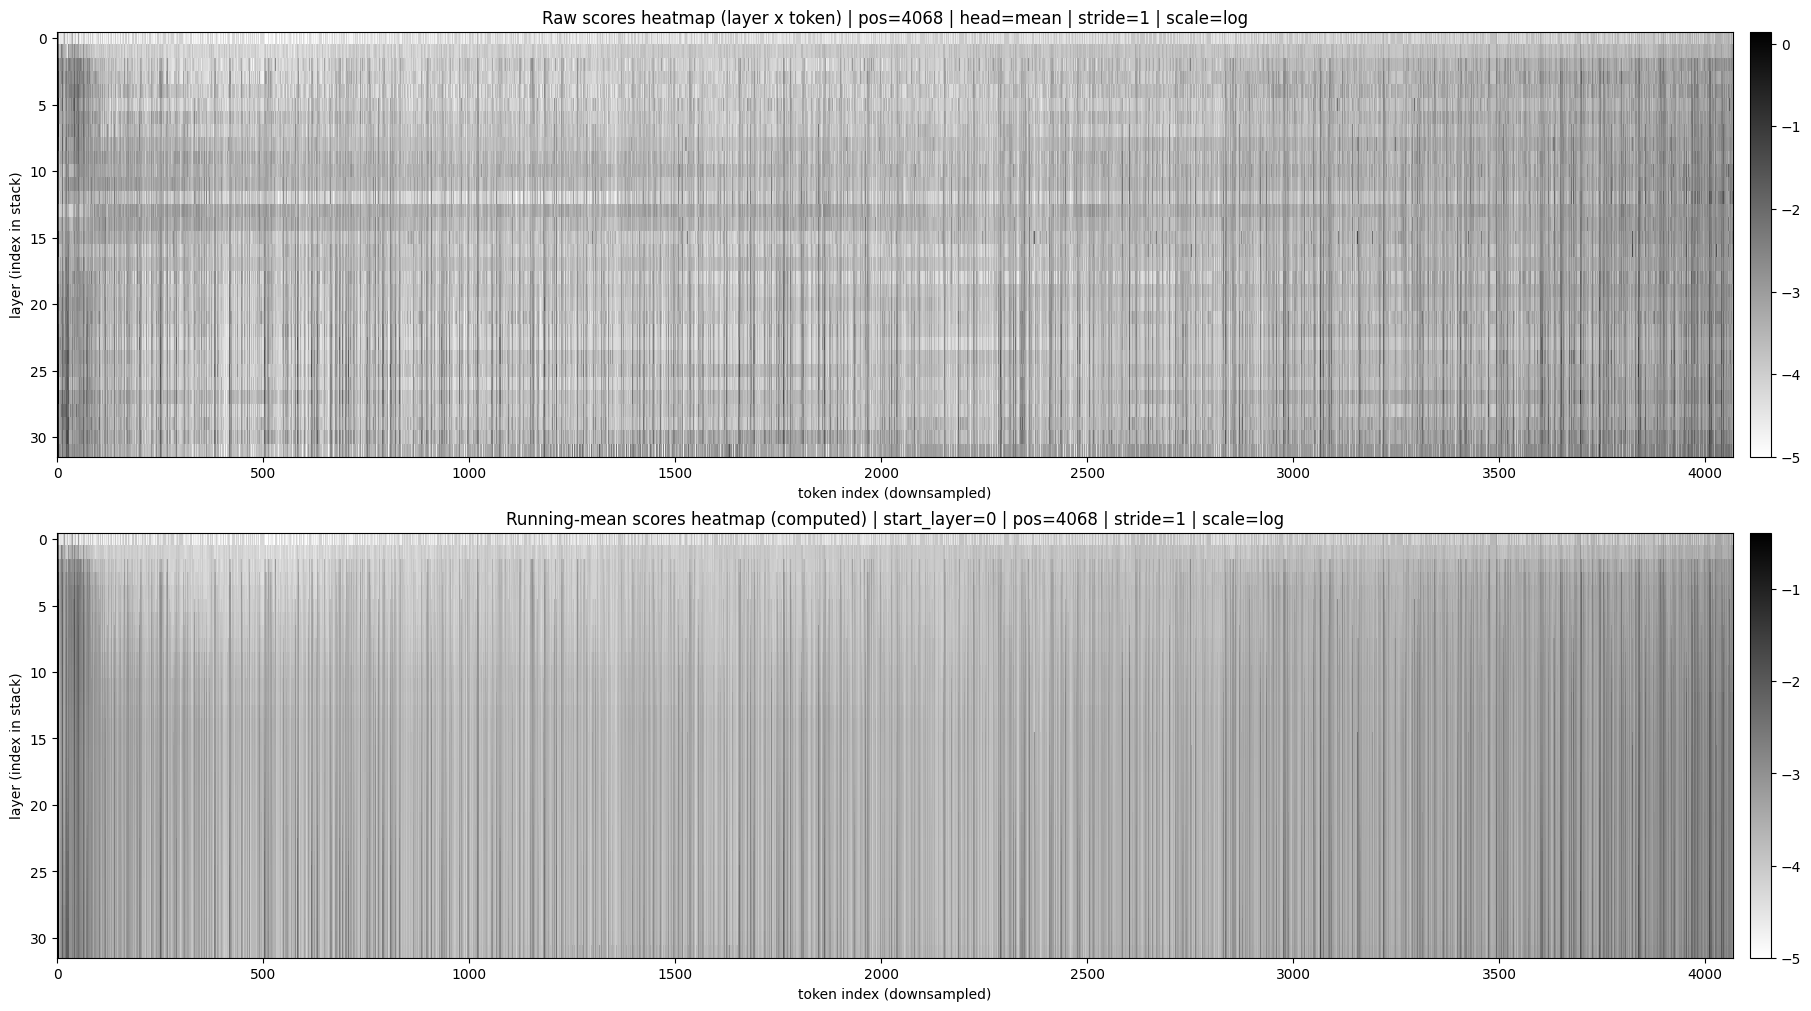

Row->layer_idx mapping:
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30, 31: 31}


In [2]:
import os
import re
from collections import defaultdict

import torch
import matplotlib.pyplot as plt

# ====== CONFIG ======
# Point this to your dump directory (contains layer*_step*_pos*.pt)
dump_dir = "/aifs4su/guhao/KVCache/kvpress/evaluation/results_debug/ruler__4096__Llama-3.1-8B-Instruct__expected_attention__cr0.0"

# Which cache_pos to visualize:
# - set to an int (e.g., 3813) to pin a specific pos
# - set to None to auto-pick the largest numeric pos found
pos = None

batch_index = 0
# Visualize score aggregated over heads (mean). If you want a specific head, set head_index to int.
head_index = None  # e.g. 0

# For large seq_len (e.g. 4096), use stride to make the heatmap smaller.
# token_stride=1 shows every token; 2/4/8 makes it faster.
token_stride = 1

# Plot scaling: "linear" or "log" (log helps when scores are very peaky)
scale = "log"

# Running-mean config (match your ScorerPress settings)
running_mean_start_layer = 0

# ====== LOAD FILES ======
FILE_RE = re.compile(r"layer(?P<layer>\d+)_step(?P<step>\d+)_pos(?P<pos>na|\d+)\.pt$")

# pos -> layer -> (step, path)
index = defaultdict(dict)
for name in os.listdir(dump_dir):
    m = FILE_RE.match(name)
    if not m:
        continue
    layer = int(m.group("layer"))
    step = int(m.group("step"))
    pos_s = m.group("pos")
    p = None if pos_s == "na" else int(pos_s)
    prev = index[p].get(layer)
    if prev is None or step > prev[0]:
        index[p][layer] = (step, os.path.join(dump_dir, name))

numeric_positions = sorted([p for p in index.keys() if p is not None])
if pos is None:
    if not numeric_positions:
        raise RuntimeError(f"No numeric pos found in {dump_dir}")
    pos = numeric_positions[-1]

if pos not in index:
    raise RuntimeError(f"pos={pos} not found. Available example pos: {numeric_positions[:5]} ... {numeric_positions[-5:]}")

layer_to_path = {layer: sp[1] for layer, sp in index[pos].items()}
layers = sorted(layer_to_path.keys())
if not layers:
    raise RuntimeError(f"No layers found for pos={pos}")

print(f"Using dump_dir={dump_dir}")
print(f"Using pos={pos}, num_layers={len(layers)}, layer range=({layers[0]}..{layers[-1]})")

# Load scores per layer
# score_vec: shape (seq_len,) after aggregating over heads
score_vecs = []
seq_len = None
for layer in layers:
    obj = torch.load(layer_to_path[layer], map_location="cpu")
    scores = obj["scores"]  # (B, H, T)
    if batch_index >= scores.shape[0]:
        raise ValueError(f"batch_index={batch_index} out of range for layer={layer}")
    s = scores[batch_index]  # (H, T)
    if head_index is None:
        s = s.mean(dim=0)  # (T,)
    else:
        s = s[int(head_index)]  # (T,)

    if seq_len is None:
        seq_len = int(s.shape[0])
    elif int(s.shape[0]) != seq_len:
        raise RuntimeError(f"seq_len mismatch: got {int(s.shape[0])} vs expected {seq_len} at layer={layer}")

    score_vecs.append(s)

S = torch.stack(score_vecs, dim=0)  # (L, T)

# Downsample tokens for plotting
S_plot = S[:, ::token_stride]

def _scale_for_plot(x: torch.Tensor, mode: str) -> torch.Tensor:
    if mode == "linear":
        return x
    if mode == "log":
        # Scores can be tiny; clamp for stability
        return torch.log10(torch.clamp(x, min=1e-12))
    raise ValueError(f"Unknown scale: {mode}")

S_scaled = _scale_for_plot(S_plot, scale)

# ====== RUNNING MEAN (computed from raw per-layer scores) ======
# running_mean layer i = average of layers [start..i]
S_rm = S.clone()
for i in range(S.shape[0]):
    layer_idx = layers[i]
    if layer_idx < running_mean_start_layer:
        continue
    # find start position in the stacked array
    # running_mean_start_layer is in absolute layer indices
    # so locate the first i0 where layers[i0] >= start
    i0 = next((j for j, li in enumerate(layers) if li >= running_mean_start_layer), None)
    if i0 is None:
        break
    if i < i0:
        continue
    S_rm[i] = S[i0 : i + 1].mean(dim=0)

S_rm_plot = S_rm[:, ::token_stride]
S_rm_scaled = _scale_for_plot(S_rm_plot, scale)

# ====== PLOT ======
fig, axes = plt.subplots(2, 1, figsize=(18, 10), constrained_layout=True)

# cmap="binary": low=white, high=black
im0 = axes[0].imshow(S_scaled.float().numpy(), aspect="auto", interpolation="nearest", cmap="binary")
axes[0].set_title(f"Raw scores heatmap (layer x token) | pos={pos} | head={'mean' if head_index is None else head_index} | stride={token_stride} | scale={scale}")
axes[0].set_ylabel("layer (index in stack)")
axes[0].set_xlabel("token index (downsampled)")
fig.colorbar(im0, ax=axes[0], fraction=0.02, pad=0.01)

im1 = axes[1].imshow(S_rm_scaled.float().numpy(), aspect="auto", interpolation="nearest", cmap="binary")
axes[1].set_title(f"Running-mean scores heatmap (computed) | start_layer={running_mean_start_layer} | pos={pos} | stride={token_stride} | scale={scale}")
axes[1].set_ylabel("layer (index in stack)")
axes[1].set_xlabel("token index (downsampled)")
fig.colorbar(im1, ax=axes[1], fraction=0.02, pad=0.01)

plt.show()

# Optional: print the mapping from stack-row -> actual layer_idx
print("Row->layer_idx mapping:")
print({i: layers[i] for i in range(len(layers))})


Scatter using raw scores: L=32, T=4069


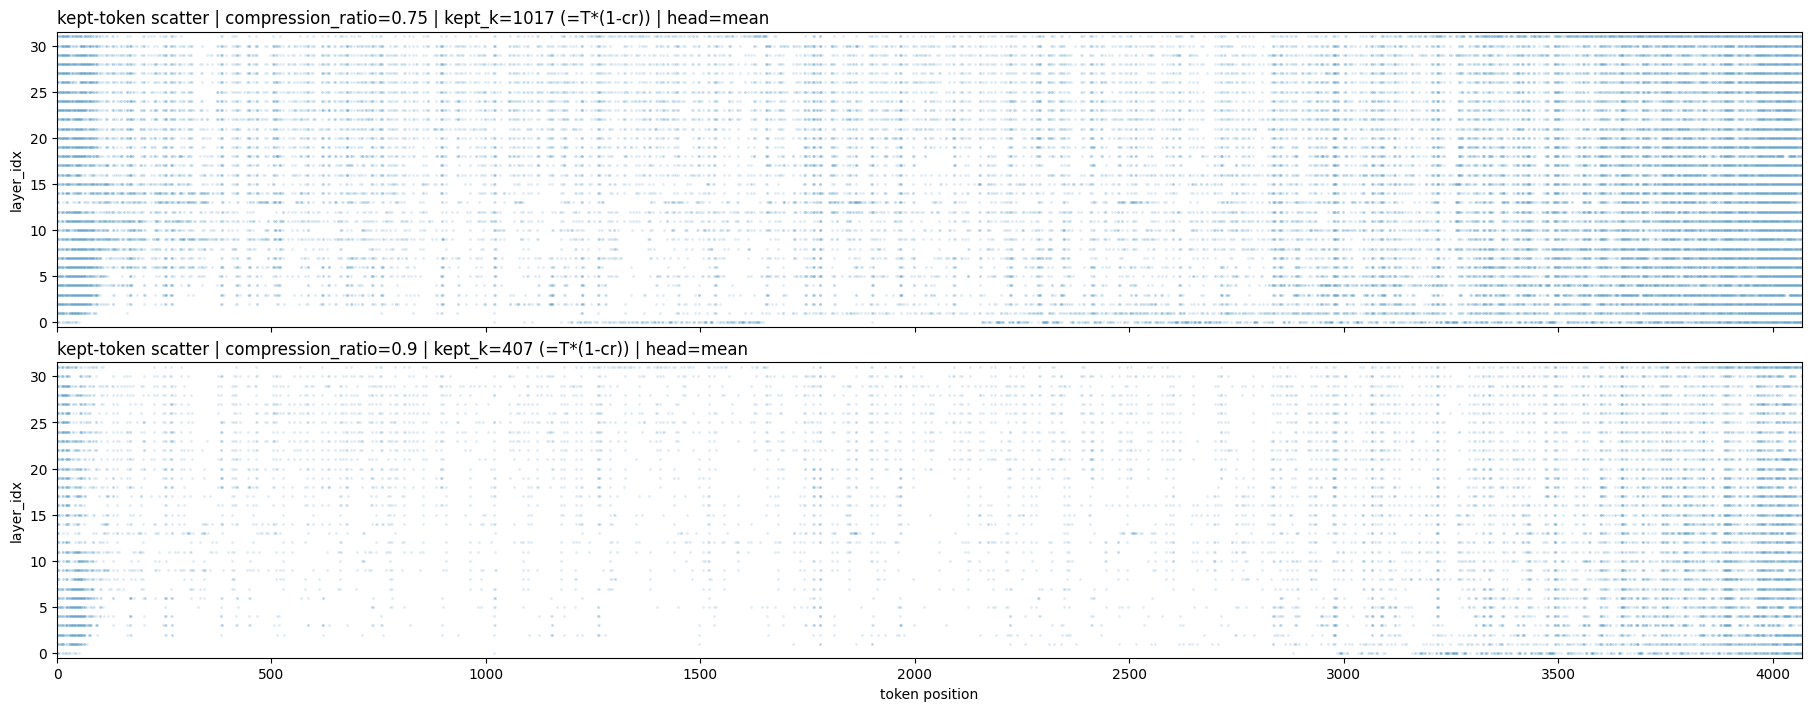

Tip: vertical dense columns => many layers select same token positions; sparse/noisy => layer-specific selections.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ====== TOPK SCATTER CONFIG ======
# Here `cr` is compression_ratio, so kept tokens fraction is (1 - cr): k = T * (1 - cr)
# crs = (0.25, 0.5, 0.75, 0.9)
crs = (0.75, 0.9)


# If True, use S_rm (running-mean) instead of raw S
use_running_mean_scores = False

# Scatter style
dot_size = 4
alpha = 0.45

# Optional: downsample the number of plotted points (1 means plot all kept-token points)
# e.g., point_stride=2 plots every other selected token index.
point_stride = 1

assert "S" in globals() and "layers" in globals(), "Run the previous cell first to load S and layers."

S_src = S_rm if use_running_mean_scores else S  # (L,T)
L, T = S_src.shape
print(f"Scatter using {'running-mean' if use_running_mean_scores else 'raw'} scores: L={L}, T={T}")

# Vertical layout: 1 column, len(crs) rows
fig, axes = plt.subplots(len(crs), 1, figsize=(18, 3.5 * len(crs)), sharex=True, sharey=True, constrained_layout=True)
if len(crs) == 1:
    axes = [axes]

for ax, cr in zip(axes, crs):
    k = int(round(T * (1.0 - float(cr))))
    k = max(1, min(T, k))

    # Build scatter coordinates
    xs_all = []
    ys_all = []

    # We do per-layer topk on the full sequence (not downsampled)
    for row_i in range(L):
        s = S_src[row_i]  # (T,)
        idx = torch.topk(s, k=k, dim=-1).indices
        idx = idx.sort().values  # keep token order
        if point_stride > 1:
            idx = idx[::point_stride]

        xs_all.append(idx.cpu().numpy())
        ys_all.append(np.full((idx.numel(),), layers[row_i], dtype=np.int32))

    xs = np.concatenate(xs_all, axis=0)
    ys = np.concatenate(ys_all, axis=0)

    ax.scatter(xs, ys, s=dot_size, alpha=alpha, linewidths=0)
    ax.set_title(
        f"kept-token scatter | compression_ratio={cr} | kept_k={k} (=T*(1-cr)) | head={'mean' if head_index is None else head_index}",
        loc="left",
    )
    ax.set_xlim(0, T - 1)
    ax.set_ylabel("layer_idx")

axes[-1].set_xlabel("token position")
axes[0].set_ylim(layers[0] - 0.5, layers[-1] + 0.5)
plt.show()

print("Tip: vertical dense columns => many layers select same token positions; sparse/noisy => layer-specific selections.")